In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
feature_df.shape

(2280, 2729)

In [6]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 32), (64, 32, 32)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_iter': [1000],
}

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'gamma': [0, 1]
}

lightgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0],
    'verbose': [-1]
}

In [7]:
feature_df.fillna(-1, inplace=True)

In [9]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: SklearnWrapper(XGBClassifier, **params),
    model_param_grid=xgb_param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='XBGClassifier',
    key_columns=TRAINGING_CONFIG['key_columns'],
)



Fold 1 training size: 1027 (50.0% of data)

--- Fold 1 | Training for target: home_goals ---

--- Fold 1 | Training for target: away_goals ---

Fold 2 training size: 1232 (60.0% of data)

--- Fold 2 | Training for target: home_goals ---

--- Fold 2 | Training for target: away_goals ---

Fold 3 training size: 1437 (70.0% of data)

--- Fold 3 | Training for target: home_goals ---

--- Fold 3 | Training for target: away_goals ---

Fold 4 training size: 1642 (80.0% of data)

--- Fold 4 | Training for target: home_goals ---

--- Fold 4 | Training for target: away_goals ---

Fold 5 training size: 1847 (90.0% of data)

--- Fold 5 | Training for target: home_goals ---

--- Fold 5 | Training for target: away_goals ---
Logged cross-validation metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0}
Logged cross-validation metrics for home_goals with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1}
Logged cross-v

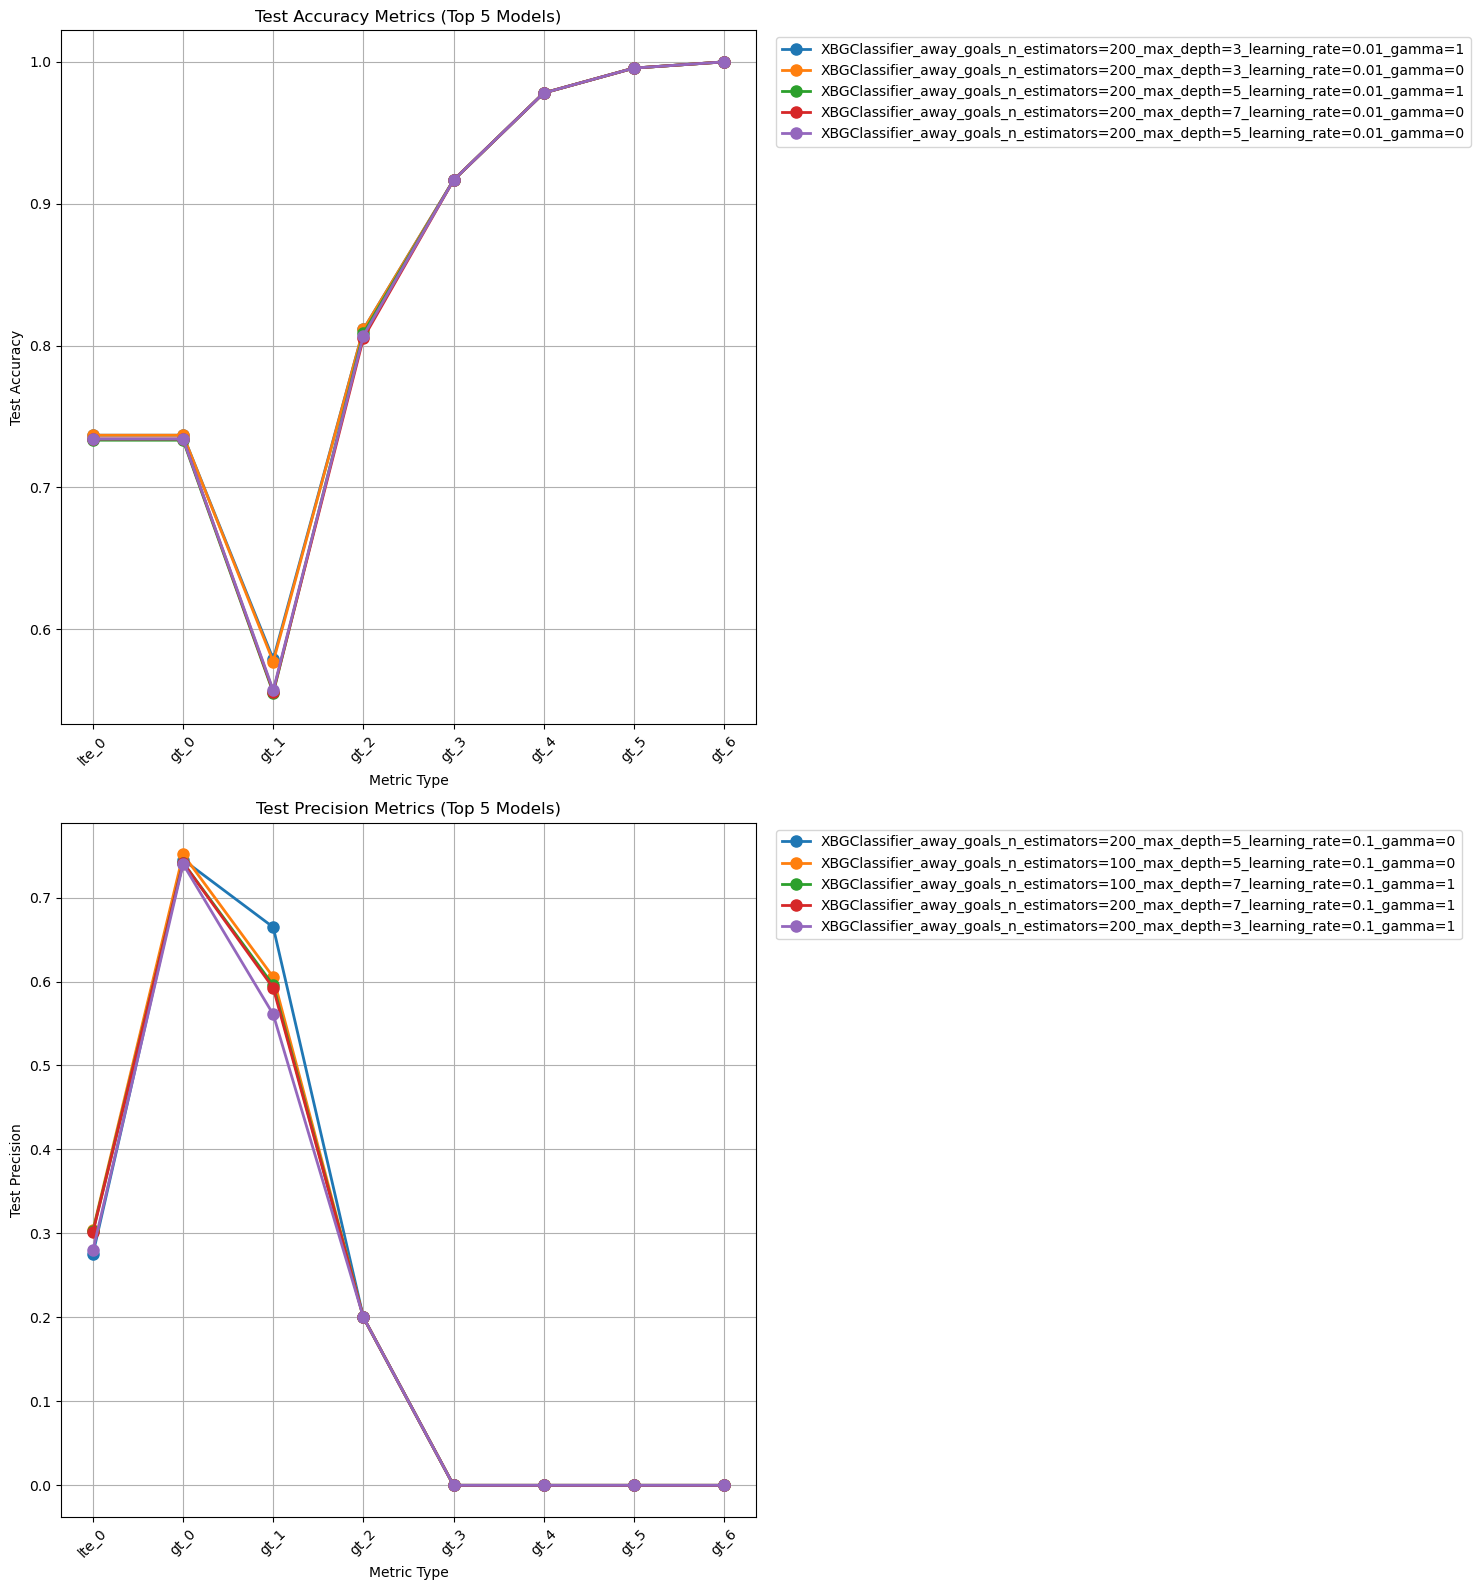

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="away_goals",
    model_name="XBGClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [ ]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="away_goals",
    model_name="LGBMClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

No matching runs found.


In [ ]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPClassifier_home_goals_hidden_layer_sizes=(64, 32, 32)_activation=relu_solver=adam_alpha=0.001_learning_rate_init=0.001_batch_size=64_max_iter=1000",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

No run found with name 'MLPClassifier_home_goals_hidden_layer_sizes=(64, 32, 32)_activation=relu_solver=adam_alpha=0.001_learning_rate_init=0.001_batch_size=64_max_iter=1000'.


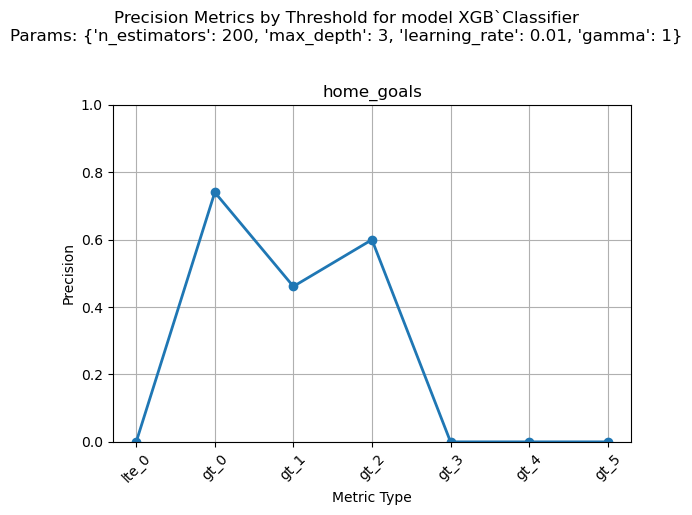

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="XGB`Classifier",
                              model_param={'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")